# 02 — Resultados do braço A (só números)

Análises definidas no [pré-registro](../PREREGISTRATION.md), commitado antes de gerar qualquer previsão de teste.
As tabelas vêm de `uv run python -m supplyrisk.analise teste` (e `final`) e ficam em `data/resultados/<periodo>/`.

- **Teste:** 2015–2024 (10 anos). **Teste final:** 2025–2026, rodado uma única vez.
- **Tarefas principais:** 17,70 m em 14 e 30 dias. As de 15,0 m são secundárias (só 2 anos com evento no teste).
- **Métrica principal:** Brier score (menor é melhor). IC 95% por bootstrap reamostrando anos.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from supplyrisk import amostras as am
from supplyrisk import avaliacao as av
from supplyrisk.experimento import RESULTADOS

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

# Paleta categórica validada (ordem fixa): Jev, melhor baseline, climatologia, análogos
COR = {"jev": "#2a78d6", "baseline": "#eb6834", "climatologia": "#1baf7a", "analogos": "#eda100"}
TINTA, TINTA_2, GRADE = "#1f1f1e", "#5f5e58", "#e6e5df"
plt.rcParams.update({"axes.edgecolor": GRADE, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2,
                     "ytick.color": TINTA_2, "axes.titlecolor": TINTA, "axes.grid": True, "grid.color": GRADE,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

TESTE = RESULTADOS / "teste"
previsoes = pd.read_parquet(TESTE / "previsoes_com_calibracao.parquet")
principais = pd.read_csv(TESTE / "comparacoes_principais.csv")
robustez = pd.read_csv(TESTE / "robustez.csv")
memoria = pd.read_csv(TESTE / "memoria.csv")
antecedencia = pd.read_csv(TESTE / "antecedencia.csv")
alarmes = pd.read_csv(TESTE / "alarmes_falsos.csv")
MELHOR = {(1770, 14): "logistica__so_manaus", (1770, 30): "logistica__so_manaus",
          (1500, 14): "gradient_boosting__so_manaus", (1500, 30): "gradient_boosting__so_manaus"}

## Contexto: como cada método aprendeu

O **Jev não foi treinado com dados do rio**. Ele já vem pronto (treinado pela TypeSafe com dados gerais) e só responde perguntas. O que ele recebeu de nós:

- a ficha de cada dia, que inclui o "nível típico para a época", um resumo calculado com 1972–1999;
- a escolha entre **2 versões** do texto da pergunta, feita com os anos 2000–2014.

Os **métodos estatísticos estudaram**: viram milhares de dias do passado com a resposta certa e se ajustaram a eles. Todos fazem a mesma prova (2015–2024). A figura é salva em português (`docs/figuras/como_cada_um_aprendeu.png`) e em inglês (`docs/figuras/como_cada_um_aprendeu_en.png`).

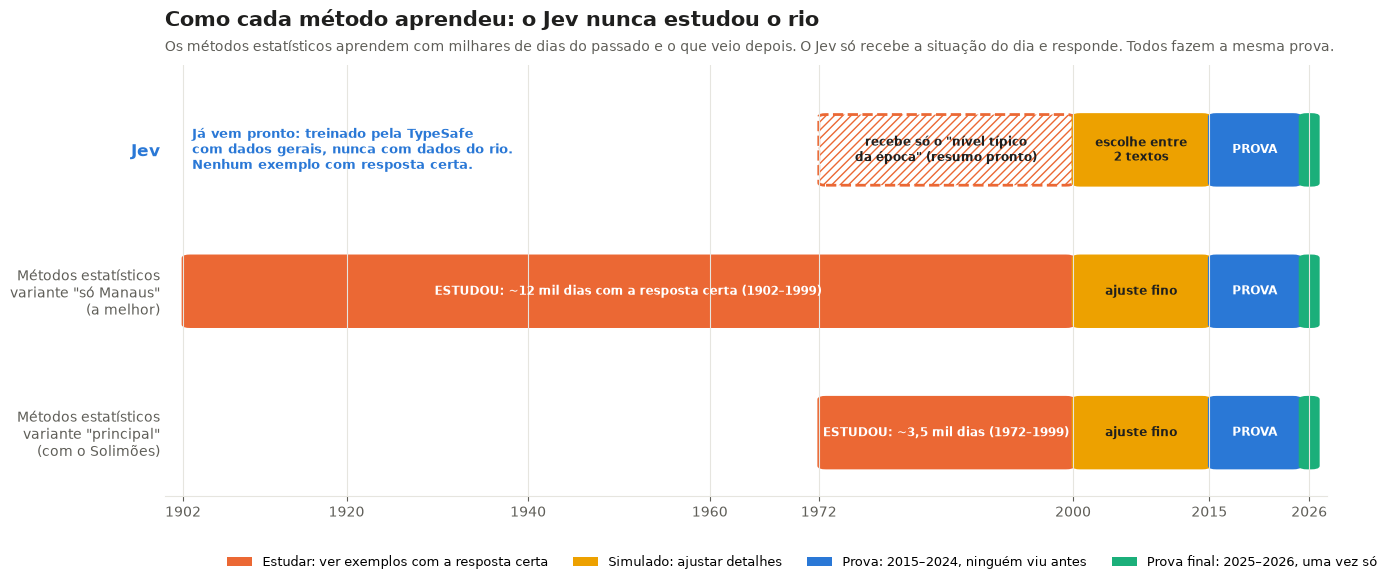

In [2]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, Patch

# Papéis de cada período (paleta categórica validada, ordem fixa)
COR_PAPEL = {"treino": "#eb6834", "validacao": "#eda100", "teste": "#2a78d6", "final": "#1baf7a"}

TEXTOS_TREINO = {
    "pt": {
        "linhas": ["Jev", "Métodos estatísticos\nvariante \"só Manaus\"\n(a melhor)",
                   "Métodos estatísticos\nvariante \"principal\"\n(com o Solimões)"],
        "jev_resumo": "recebe só o \"nível típico\nda época\" (resumo pronto)",
        "jev_textos": "escolhe entre\n2 textos",
        "jev_nota": "Já vem pronto: treinado pela TypeSafe\ncom dados gerais, nunca com dados do rio.\nNenhum exemplo com resposta certa.",
        "estudou_longo": "ESTUDOU: ~12 mil dias com a resposta certa (1902–1999)",
        "estudou_curto": "ESTUDOU: ~3,5 mil dias (1972–1999)",
        "ajuste": "ajuste fino",
        "prova": "PROVA",
        "legenda": {"treino": "Estudar: ver exemplos com a resposta certa", "validacao": "Simulado: ajustar detalhes",
                    "teste": "Prova: 2015–2024, ninguém viu antes", "final": "Prova final: 2025–2026, uma vez só"},
        "titulo": "Como cada método aprendeu: o Jev nunca estudou o rio",
        "subtitulo": "Os métodos estatísticos aprendem com milhares de dias do passado e o que veio depois. "
                     "O Jev só recebe a situação do dia e responde. Todos fazem a mesma prova.",
        "arquivo": "../docs/figuras/como_cada_um_aprendeu.png",
    },
    "en": {
        "linhas": ["Jev", "Statistical methods\n\"Manaus only\" variant\n(the best one)",
                   "Statistical methods\n\"main\" variant\n(with the Solimões)"],
        "jev_resumo": "only gets the \"typical level\nfor the season\" (ready summary)",
        "jev_textos": "picks between\n2 prompts",
        "jev_nota": "Comes pre-trained: built by TypeSafe on\ngeneral data, never on river data.\nNot a single example with the right answer.",
        "estudou_longo": "STUDIED: ~12k days with the right answer (1902–1999)",
        "estudou_curto": "STUDIED: ~3.5k days (1972–1999)",
        "ajuste": "tuning",
        "prova": "EXAM",
        "legenda": {"treino": "Study: see examples with the right answer", "validacao": "Mock exam: tune details",
                    "teste": "Exam: 2015–2024, unseen by all", "final": "Final exam: 2025–2026, run once"},
        "titulo": "How each method learned: Jev never studied the river",
        "subtitulo": "The statistical methods learn from thousands of past days and what happened next. "
                     "Jev only gets the situation of the day and answers. Everyone takes the same exam.",
        "arquivo": "../docs/figuras/como_cada_um_aprendeu_en.png",
    },
}


def faixa(ax, y, inicio, fim, papel, texto, altura=0.5, tracejada=False):
    largura = fim - inicio + 1
    ax.add_patch(FancyBboxPatch((inicio, y - altura / 2), largura, altura,
                                boxstyle="round,pad=0,rounding_size=0.8", mutation_aspect=0.02,
                                facecolor="white" if tracejada else COR_PAPEL[papel],
                                edgecolor=COR_PAPEL[papel], lw=2, ls="--" if tracejada else "-",
                                hatch="////" if tracejada else None))
    if texto:
        cor_texto = TINTA if tracejada or papel in ("validacao",) else "white"
        ax.text(inicio + largura / 2, y, texto, ha="center", va="center", fontsize=8.5,
                color=cor_texto, fontweight="bold")


def figura_treino(t):
    fig, ax = plt.subplots(figsize=(15, 5.6))

    # Jev: nada de treino no rio
    faixa(ax, 2.0, 1972, 1999, "treino", t["jev_resumo"], tracejada=True)
    faixa(ax, 2.0, 2000, 2014, "validacao", t["jev_textos"])
    faixa(ax, 2.0, 2015, 2024, "teste", t["prova"])
    faixa(ax, 2.0, 2025, 2026, "final", "")
    ax.annotate(t["jev_nota"], xy=(1903, 2.0), va="center", fontsize=9, color="#2a78d6", fontweight="bold")

    # Estatísticos
    faixa(ax, 1.0, 1902, 1999, "treino", t["estudou_longo"])
    faixa(ax, 1.0, 2000, 2014, "validacao", t["ajuste"])
    faixa(ax, 1.0, 2015, 2024, "teste", t["prova"])
    faixa(ax, 1.0, 2025, 2026, "final", "")
    faixa(ax, 0.0, 1972, 1999, "treino", t["estudou_curto"])
    faixa(ax, 0.0, 2000, 2014, "validacao", t["ajuste"])
    faixa(ax, 0.0, 2015, 2024, "teste", t["prova"])
    faixa(ax, 0.0, 2025, 2026, "final", "")

    ax.set_xlim(1900, 2028)
    ax.set_ylim(-0.45, 2.6)
    ax.set_yticks([2.0, 1.0, 0.0], t["linhas"])
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == "Jev":
            lbl.set_color("#2a78d6"); lbl.set_fontweight("bold"); lbl.set_fontsize(12)
    ax.set_xticks([1902, 1920, 1940, 1960, 1972, 2000, 2015, 2026])
    ax.grid(axis="y", visible=False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)

    fig.legend([Patch(facecolor=cor, edgecolor="none") for cor in COR_PAPEL.values()],
               [t["legenda"][papel] for papel in COR_PAPEL],
               loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.55, -0.04))
    fig.suptitle(t["titulo"], x=0.125, ha="left", fontsize=15, fontweight="bold", color=TINTA)
    fig.text(0.125, 0.905, t["subtitulo"], fontsize=10, color=TINTA_2)
    Path(t["arquivo"]).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(t["arquivo"], dpi=200, bbox_inches="tight", facecolor="white")
    return fig


figura_treino(TEXTOS_TREINO["en"])
plt.close()
figura_treino(TEXTOS_TREINO["pt"]);


## Supergráfico: o resumo em uma imagem

Para cada método, nas duas tarefas principais (17,70 m em 14 e 30 dias):

- **Acerto geral:** em quantos dias a resposta foi certa (cuidado: "sempre diz não" já acerta muito, porque a seca é rara).
- **Secas detectadas:** dos dias em que a seca veio, em quantos o método avisou.
- **Alertas que se confirmaram:** dos avisos, quantos estavam certos.
- **Erro da probabilidade (Brier):** a nota oficial do pré-registro, com margem de erro.

As três primeiras usam "aviso = probabilidade ≥ 50%" e são **complementares** (não pré-registradas). A figura é salva em português (`docs/figuras/supergrafico_braco_a.png`) e em inglês (`docs/figuras/supergrafico_braco_a_en.png`), com os mesmos números.

,tarefa,metodo,acerto,deteccao,alertas,brier,brier_ic95
0,17.70 m / 14 d,Jev (sem treino),0.930,0.652,0.670,0.042,"(0.024, 0.056)"
1,17.70 m / 14 d,Regressão logística,0.960,0.688,0.906,0.035,"(0.019, 0.053)"
2,17.70 m / 14 d,Gradient boosting,0.924,0.848,0.594,0.045,"(0.02, 0.072)"
3,17.70 m / 14 d,Anos análogos,0.929,0.402,0.818,0.053,"(0.032, 0.072)"
4,17.70 m / 14 d,Tendência (linha reta),0.932,0.929,0.615,0.052,"(0.012, 0.094)"
5,17.70 m / 14 d,Climatologia (época do ano),0.900,0.179,0.556,0.077,"(0.045, 0.11)"
6,17.70 m / 14 d,"Sempre diz ""não""",0.896,0.000,NaN,0.104,"(nan, nan)"
7,17.70 m / 30 d,Jev (sem treino),0.826,0.446,0.665,0.115,"(0.087, 0.14)"
8,17.70 m / 30 d,Regressão logística,0.848,0.521,0.718,0.104,"(0.066, 0.136)"
9,17.70 m / 30 d,Gradient boosting,0.868,0.671,0.719,0.099,"(0.056, 0.145)"


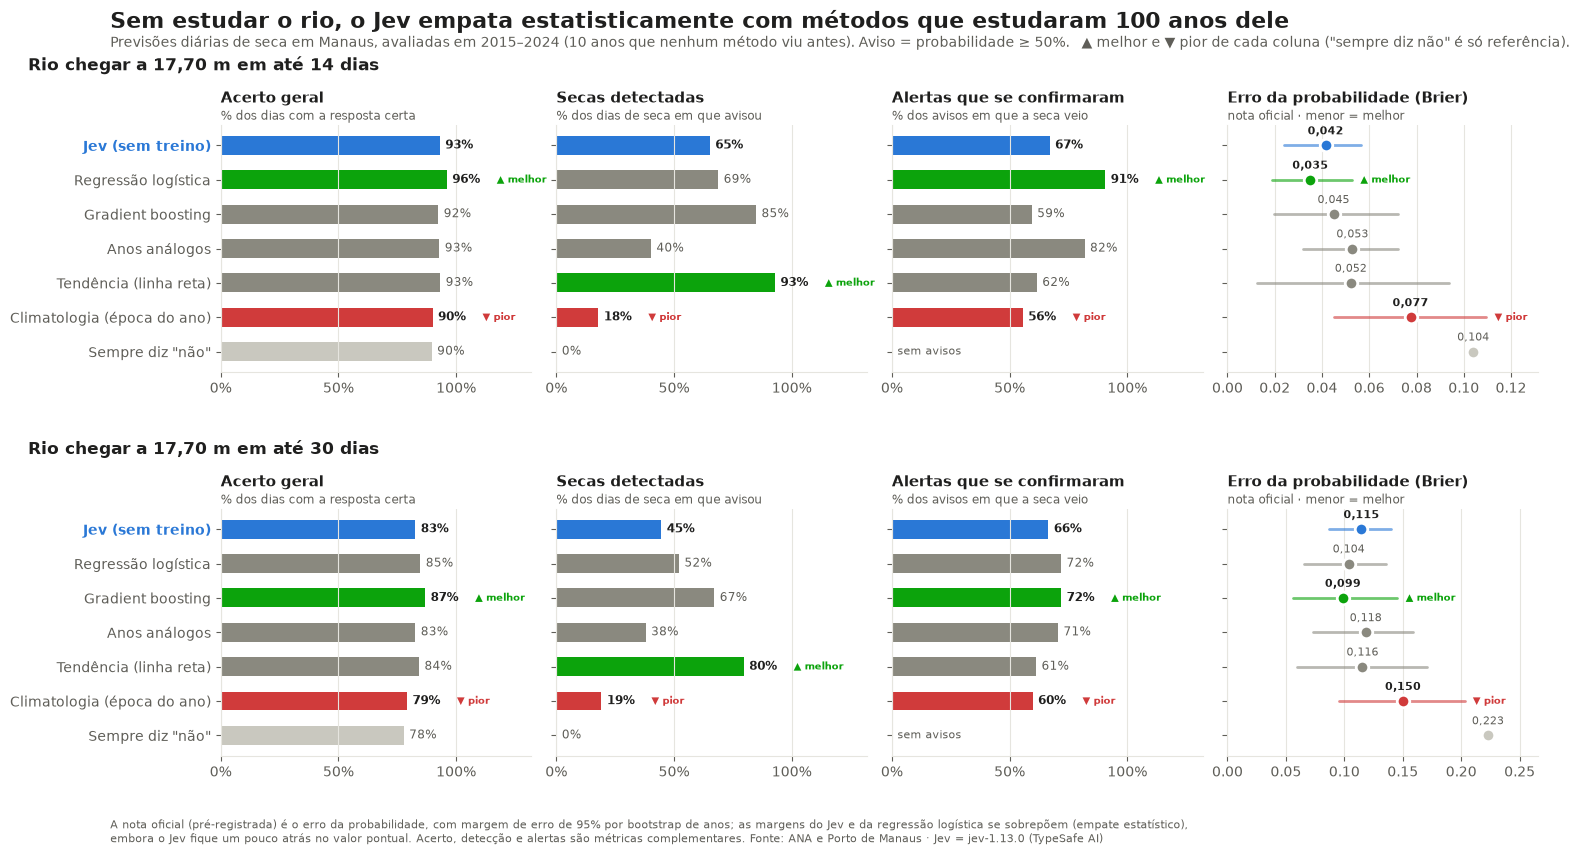

In [3]:
import numpy as np
from pathlib import Path

# Linhas do gráfico (ordem fixa). None = referência "sempre diz não".
METODOS = ["jev__principal", "logistica__so_manaus", "gradient_boosting__so_manaus",
           "analogos__so_manaus", "tendencia__so_manaus", "climatologia__principal", None]
PAINEL = ["acerto", "deteccao", "alertas", "brier"]
TAREFAS = [(1770, 14), (1770, 30)]
AZUL, CINZA, CINZA_CLARO = "#2a78d6", "#8a897f", "#c9c8bf"
VERDE, VERMELHO = "#0ca30c", "#d03b3b"  # paleta de status: sempre com ícone + rótulo

TEXTOS = {
    "pt": {
        "metodos": ["Jev (sem treino)", "Regressão logística", "Gradient boosting", "Anos análogos",
                    "Tendência (linha reta)", "Climatologia (época do ano)", "Sempre diz \"não\""],
        "titulos": {"acerto": "Acerto geral", "deteccao": "Secas detectadas",
                    "alertas": "Alertas que se confirmaram", "brier": "Erro da probabilidade (Brier)"},
        "subtitulos": {"acerto": "% dos dias com a resposta certa", "deteccao": "% dos dias de seca em que avisou",
                       "alertas": "% dos avisos em que a seca veio", "brier": "nota oficial · menor = melhor"},
        "tarefa": "Rio chegar a {m} m em até {h} dias",
        "decimal": ",",
        "melhor": "▲ melhor", "pior": "▼ pior", "sem_avisos": "sem avisos",
        "titulo": "Sem estudar o rio, o Jev empata estatisticamente com métodos que estudaram 100 anos dele",
        "subtitulo": "Previsões diárias de seca em Manaus, avaliadas em 2015–2024 (10 anos que nenhum método viu antes). "
                     "Aviso = probabilidade ≥ 50%.   ▲ melhor e ▼ pior de cada coluna (\"sempre diz não\" é só referência).",
        "rodape": "A nota oficial (pré-registrada) é o erro da probabilidade, com margem de erro de 95% por bootstrap de anos; "
                  "as margens do Jev e da regressão logística se sobrepõem (empate estatístico),\nembora o Jev fique um pouco "
                  "atrás no valor pontual. Acerto, detecção e alertas são métricas complementares. "
                  "Fonte: ANA e Porto de Manaus · Jev = jev-1.13.0 (TypeSafe AI)",
        "arquivo": "../docs/figuras/supergrafico_braco_a.png",
    },
    "en": {
        "metodos": ["Jev (no training)", "Logistic regression", "Gradient boosting", "Analog years",
                    "Trend (straight line)", "Climatology (time of year)", "Always says \"no\""],
        "titulos": {"acerto": "Accuracy", "deteccao": "Droughts detected",
                    "alertas": "Alerts that came true", "brier": "Probability error (Brier)"},
        "subtitulos": {"acerto": "% of days with the right answer", "deteccao": "% of drought days it warned about",
                       "alertas": "% of warnings followed by drought", "brier": "official score · lower = better"},
        "tarefa": "River reaching {m} m within {h} days",
        "decimal": ".",
        "melhor": "▲ best", "pior": "▼ worst", "sem_avisos": "no warnings",
        "titulo": "Without studying the river, Jev statistically ties methods trained on 100 years of it",
        "subtitulo": "Daily drought forecasts for the Rio Negro at Manaus, Brazil, scored on 2015–2024 (10 years no method had seen). "
                     "Warning = probability ≥ 50%.   ▲ best and ▼ worst in each column (\"always says no\" is a reference only).",
        "rodape": "The official (pre-registered) score is the probability error, with 95% intervals from a bootstrap over years; "
                  "Jev's and logistic regression's intervals overlap (statistical tie),\nalthough Jev is slightly behind on the point "
                  "estimate. Accuracy, detection and alerts are complementary metrics. "
                  "Data: ANA and Port of Manaus · Jev = jev-1.13.0 (TypeSafe AI)",
        "arquivo": "../docs/figuras/supergrafico_braco_a_en.png",
    },
}


def numeros(g, coluna):
    y = g["rotulo"].to_numpy().astype(bool)
    p = np.zeros(len(y)) if coluna is None else g[coluna].to_numpy()
    alerta = p >= 0.5
    valores = {
        "acerto": (alerta == y).mean(),
        "deteccao": (alerta & y).sum() / y.sum(),
        "alertas": (alerta & y).sum() / alerta.sum() if alerta.any() else np.nan,
        "brier": av.brier(y, p),
    }
    ic = av.bootstrap_por_ano(g.assign(_p=p), "_p")["brier_ic95"] if coluna else (np.nan, np.nan)
    return valores, ic


def melhor_e_pior(resultados, chave):
    """Índices do melhor e do pior método numa coluna. "Sempre diz não" é só referência: fica de fora."""
    candidatos = {i: r[chave] for i, (coluna, r, _) in enumerate(resultados)
                  if coluna is not None and not np.isnan(r[chave])}
    menor_e_melhor = chave == "brier"
    melhor = (min if menor_e_melhor else max)(candidatos, key=candidatos.get)
    pior = (max if menor_e_melhor else min)(candidatos, key=candidatos.get)
    return melhor, pior


# Números calculados uma vez; as duas línguas desenham os mesmos valores.
resultados_por_tarefa = {}
for limiar, h in TAREFAS:
    g = previsoes[(previsoes["limiar_cm"] == limiar) & (previsoes["horizonte_dias"] == h)]
    resultados_por_tarefa[(limiar, h)] = [(coluna, *numeros(g, coluna)) for coluna in METODOS]


def supergrafico(t):
    fig, eixos = plt.subplots(2, 4, figsize=(17, 8.2), sharey=True, gridspec_kw={"wspace": 0.08, "hspace": 0.55})
    for linha_eixos, (limiar, h) in zip(eixos, TAREFAS):
        resultados = resultados_por_tarefa[(limiar, h)]
        for ax, chave in zip(linha_eixos, PAINEL):
            melhor, pior = melhor_e_pior(resultados, chave)
            for i, (coluna, valores, (lo, hi)) in enumerate(resultados):
                v = valores[chave]
                if np.isnan(v):
                    ax.annotate(t["sem_avisos"], (0, i), xytext=(4, 0), textcoords="offset points", va="center",
                                fontsize=8, color=TINTA_2)
                    continue
                e_jev = coluna == "jev__principal"
                # O Jev mantém o azul (identidade); os demais ganham a cor de status quando são o melhor ou o pior.
                cor = AZUL if e_jev else CINZA_CLARO if coluna is None else VERDE if i == melhor else VERMELHO if i == pior else CINZA
                destaque = e_jev or i in (melhor, pior)
                etiqueta = t["melhor"] if i == melhor else t["pior"] if i == pior else ""
                cor_etiqueta = VERDE if i == melhor else VERMELHO
                estilo = dict(color=TINTA if destaque else TINTA_2, fontweight="bold" if destaque else "normal")
                if chave == "brier":
                    if not np.isnan(lo):
                        ax.plot([lo, hi], [i, i], color=cor, lw=2, solid_capstyle="round", alpha=0.6)
                    ax.plot(v, i, "o", ms=9, color=cor, mec="white", mew=2)
                    ax.annotate(f"{v:.3f}".replace(".", t["decimal"]), (v, i), xytext=(0, 8),
                                textcoords="offset points", ha="center", fontsize=8, **estilo)
                    if etiqueta:
                        ax.annotate(etiqueta, (hi if not np.isnan(hi) else v, i), xytext=(6, 0), textcoords="offset points",
                                    va="center", fontsize=7.5, color=cor_etiqueta, fontweight="bold")
                else:
                    ax.barh(i, v, height=0.55, color=cor)
                    ax.annotate(f"{v:.0%}", (v, i), xytext=(4, 0), textcoords="offset points", va="center",
                                fontsize=8.5, **estilo)
                    if etiqueta:
                        ax.annotate(etiqueta, (v, i), xytext=(36, 0), textcoords="offset points", va="center",
                                    fontsize=7.5, color=cor_etiqueta, fontweight="bold")
        for ax, chave in zip(linha_eixos, PAINEL):
            ax.set_title(t["titulos"][chave], pad=16, fontsize=10.5, loc="left", color=TINTA, fontweight="bold")
            ax.text(0, 1.02, t["subtitulos"][chave], transform=ax.transAxes, fontsize=8.5, color=TINTA_2)
            if chave == "brier":
                ax.set_xlim(0, ax.get_xlim()[1] * 1.15)
            else:
                ax.set_xlim(0, 1.32)
                ax.set_xticks([0, 0.5, 1], ["0%", "50%", "100%"])
            ax.grid(axis="y", visible=False)
        linha_eixos[0].set_yticks(range(len(METODOS)), t["metodos"])
        metros = f"{limiar / 100:.2f}".replace(".", t["decimal"])
        linha_eixos[0].text(-0.62, 1.22, t["tarefa"].format(m=metros, h=h), transform=linha_eixos[0].transAxes,
                            fontsize=12.5, fontweight="bold", color=TINTA)
        for lbl in linha_eixos[0].get_yticklabels():
            if lbl.get_text().startswith("Jev"):
                lbl.set_color(AZUL); lbl.set_fontweight("bold")

    eixos[0, 0].invert_yaxis()  # uma vez só: os eixos y são compartilhados
    fig.suptitle(t["titulo"], x=0.06, y=1.02, ha="left", fontsize=16, fontweight="bold", color=TINTA)
    fig.text(0.06, 0.975, t["subtitulo"], fontsize=10, color=TINTA_2)
    fig.text(0.06, 0.005, t["rodape"], fontsize=8, color=TINTA_2)
    Path(t["arquivo"]).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(t["arquivo"], dpi=200, bbox_inches="tight", facecolor="white")
    return fig


supergrafico(TEXTOS["en"])
plt.close()
supergrafico(TEXTOS["pt"])

pd.DataFrame([
    {"tarefa": f"{l / 100:.2f} m / {h} d", "metodo": nome, **valores, "brier_ic95": (round(lo, 3), round(hi, 3))}
    for (l, h), resultados in resultados_por_tarefa.items()
    for nome, (coluna, valores, (lo, hi)) in zip(TEXTOS["pt"]["metodos"], resultados)
]).round(3)


## 1. Comparações principais

1. **Jev bruto × climatologia:** o Jev tem habilidade sem nenhum treino?
2. **Jev calibrado × melhor baseline calibrado:** com o mesmo acesso à validação, o Jev compete?

`diferenca` = Brier do Jev − Brier do outro (negativo = Jev melhor). O veredito vem do IC 95%.

In [4]:
principais[["tarefa", "tipo", "comparacao", "brier_jev", "brier_outro", "outro", "diferenca", "ic95", "veredito"]].round(4)

,tarefa,tipo,comparacao,brier_jev,brier_outro,outro,diferenca,ic95,veredito
0,15.00 m / 14 d,secundária,1. Jev bruto × climatologia,0.0094,0.0234,climatologia__principal,-0.0140,"(np.float64(-0.0428), np.float64(0.0065))",empate (IC contém 0)
1,15.00 m / 14 d,secundária,2. Jev calibrado × melhor baseline calibrado,0.0094,0.0065,gradient_boosting__so_manaus__cal,0.0029,"(np.float64(-0.001), np.float64(0.0088))",empate (IC contém 0)
2,15.00 m / 14 d,secundária,extra: Jev bruto × melhor baseline bruto,0.0094,0.0100,gradient_boosting__so_manaus,-0.0006,"(np.float64(-0.0097), np.float64(0.0075))",empate (IC contém 0)
3,15.00 m / 30 d,secundária,1. Jev bruto × climatologia,0.0340,0.0456,climatologia__principal,-0.0116,"(np.float64(-0.0569), np.float64(0.0211))",empate (IC contém 0)
4,15.00 m / 30 d,secundária,2. Jev calibrado × melhor baseline calibrado,0.0350,0.0373,gradient_boosting__so_manaus__cal,-0.0022,"(np.float64(-0.0227), np.float64(0.0119))",empate (IC contém 0)
5,15.00 m / 30 d,secundária,extra: Jev bruto × melhor baseline bruto,0.0340,0.0394,gradient_boosting__so_manaus,-0.0054,"(np.float64(-0.0454), np.float64(0.0215))",empate (IC contém 0)
6,17.70 m / 14 d,principal,1. Jev bruto × climatologia,0.0415,0.0775,climatologia__principal,-0.0359,"(np.float64(-0.0623), np.float64(-0.0074))",Jev melhor
7,17.70 m / 14 d,principal,2. Jev calibrado × melhor baseline calibrado,0.0430,0.0351,logistica__so_manaus__cal,0.0079,"(np.float64(-0.0034), np.float64(0.0206))",empate (IC contém 0)
8,17.70 m / 14 d,principal,extra: Jev bruto × melhor baseline bruto,0.0415,0.0351,logistica__so_manaus,0.0065,"(np.float64(-0.0044), np.float64(0.0188))",empate (IC contém 0)
9,17.70 m / 30 d,principal,1. Jev bruto × climatologia,0.1146,0.1502,climatologia__principal,-0.0356,"(np.float64(-0.0762), np.float64(0.0039))",empate (IC contém 0)


## 2. Brier por método, com IC 95%

Cada ponto é o Brier no teste, e a barra é o IC 95% (bootstrap por ano). Quanto mais à esquerda, melhor.

,tarefa,metodo,brier,lo,hi
0,15.00 m / 14 d,Climatologia,0.0234,0.0001,0.0592
1,15.00 m / 14 d,Análogos (só Manaus),0.0094,0.0010,0.0220
2,15.00 m / 14 d,"Melhor baseline, calibrado",0.0065,0.0000,0.0165
3,15.00 m / 14 d,Jev bruto,0.0094,0.0023,0.0178
4,15.00 m / 14 d,Jev calibrado,0.0094,0.0014,0.0191
5,15.00 m / 30 d,Climatologia,0.0456,0.0003,0.1147
6,15.00 m / 30 d,Análogos (só Manaus),0.0259,0.0014,0.0635
7,15.00 m / 30 d,"Melhor baseline, calibrado",0.0373,0.0000,0.0938
8,15.00 m / 30 d,Jev bruto,0.0340,0.0145,0.0597
9,15.00 m / 30 d,Jev calibrado,0.0350,0.0036,0.0777


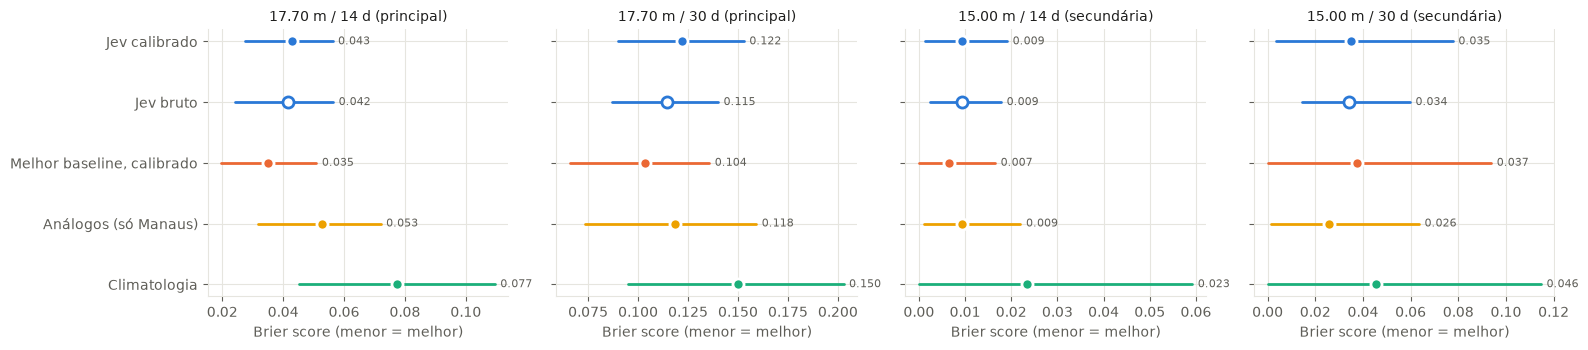

In [5]:
linhas = []
for (limiar, h), g in previsoes.groupby(["limiar_cm", "horizonte_dias"]):
    for nome, coluna, cor in [
        ("Climatologia", "climatologia__principal", COR["climatologia"]),
        ("Análogos (só Manaus)", "analogos__so_manaus", COR["analogos"]),
        ("Melhor baseline, calibrado", MELHOR[(limiar, h)] + "__cal", COR["baseline"]),
        ("Jev bruto", "jev__principal", COR["jev"]),
        ("Jev calibrado", "jev__principal__cal", COR["jev"]),
    ]:
        lo, hi = av.bootstrap_por_ano(g, coluna)["brier_ic95"]
        linhas.append({"tarefa": f"{limiar / 100:.2f} m / {h} d", "metodo": nome, "cor": cor,
                       "brier": av.brier(g["rotulo"], g[coluna]), "lo": lo, "hi": hi})
tabela_brier = pd.DataFrame(linhas)

tarefas = ["17.70 m / 14 d", "17.70 m / 30 d", "15.00 m / 14 d", "15.00 m / 30 d"]
fig, eixos = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, tarefa in zip(eixos, tarefas):
    t = tabela_brier[tabela_brier["tarefa"] == tarefa].reset_index(drop=True)
    for i, r in t.iterrows():
        ax.plot([r.lo, r.hi], [i, i], color=r.cor, lw=2, solid_capstyle="round")
        vazio = r.metodo == "Jev bruto"
        ax.plot(r.brier, i, "o", ms=8, color=r.cor, mec=r.cor if vazio else "white", mew=2,
                mfc="white" if vazio else r.cor)
        ax.annotate(f"{r.brier:.3f}", (r.hi, i), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8, color=TINTA_2)
    ax.set_yticks(range(len(t)), t["metodo"])
    ax.set_title(tarefa + (" (principal)" if tarefa.startswith("17") else " (secundária)"), fontsize=10)
    ax.set_xlabel("Brier score (menor = melhor)")
    ax.invert_yaxis()
plt.tight_layout()
tabela_brier.drop(columns="cor").round(4)

## 3. Calibração: quando o método diz X%, acontece X% das vezes?

Tarefas principais. A diagonal é a calibração perfeita. Faixas com poucas amostras são menos confiáveis; o número de amostras de cada faixa está na tabela.

n  prevista  observada
tarefa         metodo                     faixa                                  
17.70 m / 14 d Jev bruto                  (-0.001, 0.2]  919     0.011      0.013
                                          (0.2, 0.4]      30     0.308      0.400
                                          (0.4, 0.6]      42     0.510      0.667
                                          (0.6, 0.8]      58     0.712      0.552
                                          (0.8, 1.0]      28     0.870      1.000
               Jev calibrado              (-0.001, 0.2]  926     0.008      0.015
                                          (0.2, 0.4]      37     0.296      0.568
                                          (0.4, 0.6]      38     0.507      0.579
                                          (0.6, 0.8]      51     0.700      0.588
                                          (0.8, 1.0]      25     0.870      1.000
               Melhor baseline, calibrado (-0.001, 0.2]  941     0.008      0.028
                                          (0.2, 0.4]      49     0.272      0.184
                                          (0.4, 0.6]      16     0.482      0.562
                                          (0.6, 0.8]       7     0.699      0.714
                                          (0.8, 1.0]      64     0.970      0.984
17.70 m / 30 d Jev bruto                  (-0.001, 0.2]  780     0.027      0.071
                                          (0.2, 0.4]      92     0.294      0.587
                                          (0.4, 0.6]      83     0.497      0.578
                                          (0.6, 0.8]      77     0.722      0.558
                                          (0.8, 1.0]      45     0.870      0.889
               Jev calibrado              (-0.001, 0.2]  819     0.026      0.088
                                          (0.2, 0.4]     101     0.300      0.614
                                          (0.4, 0.6]      63     0.492      0.683
                                          (0.6, 0.8]      72     0.700      0.569
                                          (0.8, 1.0]      22     0.859      1.000
               Melhor baseline, calibrado (-0.001, 0.2]  813     0.012      0.079
                                          (0.2, 0.4]      70     0.294      0.571
                                          (0.4, 0.6]      43     0.498      0.512
                                          (0.6, 0.8]      57     0.697      0.351
                                          (0.8, 1.0]      94     0.941      1.000

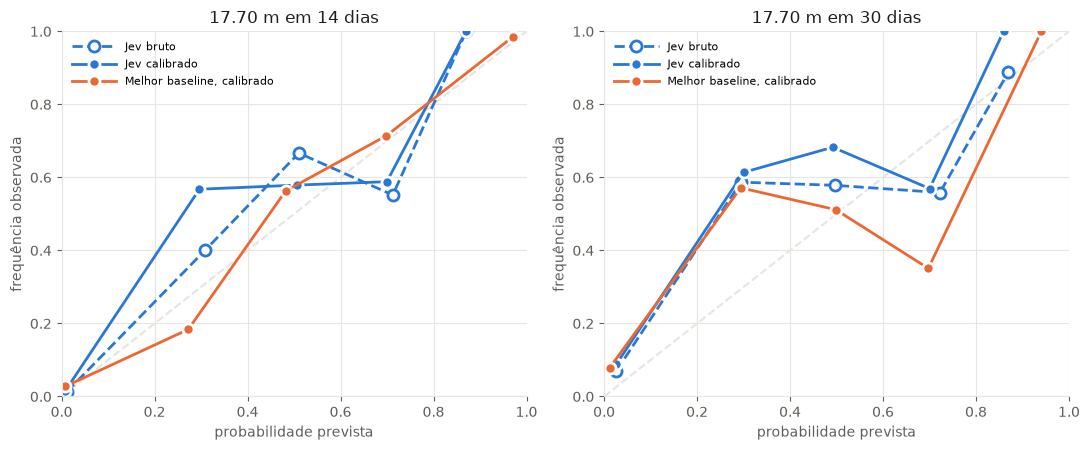

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6))
tabelas = {}
for ax, (limiar, h) in zip(eixos, [(1770, 14), (1770, 30)]):
    g = previsoes[(previsoes["limiar_cm"] == limiar) & (previsoes["horizonte_dias"] == h)]
    ax.plot([0, 1], [0, 1], color=GRADE, lw=1.5, ls="--")
    for nome, coluna, cor, vazio in [("Jev bruto", "jev__principal", COR["jev"], True),
                                     ("Jev calibrado", "jev__principal__cal", COR["jev"], False),
                                     ("Melhor baseline, calibrado", MELHOR[(limiar, h)] + "__cal", COR["baseline"], False)]:
        c = av.confiabilidade(g["rotulo"], g[coluna], bins=5)
        tabelas[(f"{limiar / 100:.2f} m / {h} d", nome)] = c
        ax.plot(c["prevista"], c["observada"], "--o" if vazio else "-o", color=cor, lw=2, ms=8,
                mec=cor if vazio else "white", mew=2, mfc="white" if vazio else cor, label=nome)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="probabilidade prevista", ylabel="frequência observada",
           title=f"{limiar / 100:.2f} m em {h} dias")
    ax.legend(frameon=False, fontsize=8, loc="upper left", handlelength=4)
plt.tight_layout()
pd.concat(tabelas, names=["tarefa", "metodo"]).round(3)

## 4. Um ano de perto: 2024 (seca recorde)

No painel de cima, a probabilidade de a cota chegar a 17,70 m em 30 dias, dia a dia. No de baixo, a cota real. São dois painéis separados para não pôr dois eixos y no mesmo gráfico.

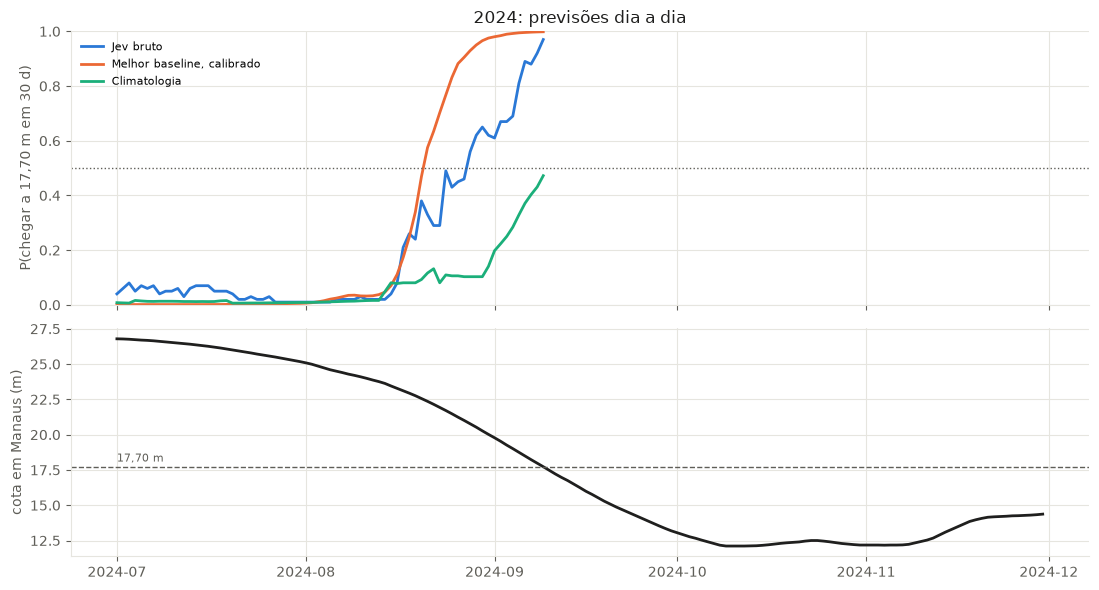

In [7]:
serie, _ = am.carregar_series()
ano, limiar, h = 2024, 1770, 30
g = previsoes[(previsoes["ano"] == ano) & (previsoes["limiar_cm"] == limiar) & (previsoes["horizonte_dias"] == h)].sort_values("data")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})
for nome, coluna, cor in [("Jev bruto", "jev__principal", COR["jev"]),
                          ("Melhor baseline, calibrado", MELHOR[(limiar, h)] + "__cal", COR["baseline"]),
                          ("Climatologia", "climatologia__principal", COR["climatologia"])]:
    a1.plot(g["data"], g[coluna], color=cor, lw=2, label=nome)
a1.axhline(0.5, color=TINTA_2, lw=1, ls=":")
a1.set(ylim=(0, 1), ylabel="P(chegar a 17,70 m em 30 d)", title=f"{ano}: previsões dia a dia")
a1.legend(frameon=False, fontsize=8, loc="upper left")
trecho = serie[f"{ano}-07-01":f"{ano}-11-30"] / 100
a2.plot(trecho.index, trecho, color=TINTA, lw=2)
a2.axhline(limiar / 100, color=TINTA_2, lw=1, ls="--")
a2.annotate("17,70 m", (trecho.index[0], limiar / 100), xytext=(0, 4), textcoords="offset points", fontsize=8, color=TINTA_2)
a2.set(ylabel="cota em Manaus (m)")
plt.tight_layout()

## 5. Robustez do Jev

Mudanças que não deveriam alterar a resposta: o nome das opções, a ordem das opções e o tipo de pergunta. `decisoes_invertidas` é a fração de dias em que a decisão (P ≥ 0,5) muda em relação à versão principal.

In [8]:
robustez.assign(tarefa=lambda d: d["limiar_cm"].div(100).map("{:.2f} m".format) + " / " + d["horizonte_dias"].astype(str) + " d")[
    ["tarefa", "variante", "brier_principal", "brier", "dif_abs_media", "decisoes_invertidas"]].round(4)

,tarefa,variante,brier_principal,brier,dif_abs_media,decisoes_invertidas
0,15.00 m / 14 d,nomes_01,0.0094,0.0095,0.0041,0.0042
1,15.00 m / 14 d,nomes_sim_nao,0.0094,0.0103,0.0046,0.0042
2,15.00 m / 14 d,ordem_invertida,0.0094,0.0096,0.0041,0.0051
3,15.00 m / 14 d,com_datas,0.0094,0.0104,0.0033,0.0051
4,15.00 m / 14 d,noul,0.0094,0.0126,0.0374,0.0093
5,15.00 m / 30 d,nomes_01,0.0340,0.0342,0.0104,0.0025
6,15.00 m / 30 d,nomes_sim_nao,0.0340,0.0364,0.0135,0.0068
7,15.00 m / 30 d,ordem_invertida,0.0340,0.0337,0.0111,0.0059
8,15.00 m / 30 d,com_datas,0.0340,0.0352,0.0097,0.0051
9,15.00 m / 30 d,noul,0.0340,0.0430,0.0588,0.0186


## 6. Teste de memória

A mesma pergunta, mas com a data e o ano no estado. Se o Jev lembrasse das secas conhecidas, o Brier **com datas** cairia nos anos de seca, o que apareceria como valores negativos na tabela.

In [9]:
memoria.pivot_table(index=["ano", "cruzou"], columns=["limiar_cm", "horizonte_dias"], values="com_menos_sem").round(4)

limiar_cm         1500            1770        
horizonte_dias      14      30      14      30
ano  cruzou                                   
2015 0          0.0033  0.0010     NaN     NaN
     1             NaN     NaN -0.0039  0.0000
2016 0          0.0000 -0.0006     NaN     NaN
     1             NaN     NaN  0.0004 -0.0039
2017 0          0.0000 -0.0045     NaN     NaN
     1             NaN     NaN  0.0003  0.0015
2018 0          0.0013  0.0032     NaN     NaN
     1             NaN     NaN  0.0015 -0.0018
2019 0          0.0000 -0.0009  0.0024  0.0029
2020 0         -0.0001 -0.0026     NaN     NaN
     1             NaN     NaN  0.0026  0.0090
2021 0          0.0000 -0.0000  0.0002  0.0046
2022 0          0.0006 -0.0028     NaN     NaN
     1             NaN     NaN  0.0004  0.0036
2023 1          0.0035  0.0109  0.0021  0.0033
2024 1          0.0031  0.0148  0.0063  0.0126

## 7. Antecedência e alarmes falsos

- **Antecedência:** quantos dias seguidos o método ficou com P ≥ 0,5 antes do primeiro cruzamento.
- **Alarme falso:** um ano sem cruzamento em que o método passou de 0,5 em algum dia.

In [10]:
antecedencia.pivot_table(index=["limiar_cm", "horizonte_dias", "ano"], columns="metodo", values="dias_de_alerta")

metodo                         analogos__so_manaus  climatologia__principal  gradient_boosting__so_manaus  jev__principal  jev__principal__cal  logistica__so_manaus
limiar_cm horizonte_dias ano                                                                                                                                        
1500      14             2023                  7.0                      0.0                           8.0            10.0                 10.0                   7.0
                         2024                  7.0                      0.0                           7.0             7.0                  7.0                   7.0
          30             2023                 12.0                      0.0                          10.0            12.0                 10.0                  15.0
                         2024                 13.0                      0.0                           0.0            11.0                 10.0                  16.0
1770      14             2015                  3.0                      3.0                           9.0             6.0                  6.0                  10.0
                         2016                  0.0                      0.0                          32.0             3.0                  3.0                   0.0
                         2017                 12.0                      7.0                          12.0            11.0                 10.0                  11.0
                         2018                  1.0                      0.0                          11.0            10.0                  9.0                   0.0
                         2020                  9.0                      5.0                          15.0            10.0                 10.0                  14.0
                         2022                  6.0                      3.0                          12.0             8.0                  8.0                   9.0
                         2023                  6.0                      2.0                          10.0             5.0                  5.0                   9.0
                         2024                  8.0                      0.0                          13.0             9.0                  6.0                  11.0
          30             2015                  6.0                      4.0                          11.0            12.0                  6.0                  13.0
                         2016                  0.0                      0.0                          79.0             4.0                  3.0                   0.0
                         2017                 26.0                     17.0                          32.0            14.0                 11.0                  28.0
                         2018                  3.0                      0.0                          13.0            15.0                  9.0                   2.0
                         2020                 17.0                     11.0                          17.0            13.0                  9.0                  20.0
                         2022                 10.0                      6.0                          22.0            11.0                  9.0                  16.0
                         2023                 13.0                      8.0                          18.0             8.0                  5.0                  15.0
                         2024                 16.0                      0.0                          20.0            13.0                 12.0                  20.0

In [11]:
alarmes.pivot_table(index=["limiar_cm", "horizonte_dias", "anos_sem_evento"], columns="metodo", values="anos_com_alarme_falso")

metodo                                    analogos__so_manaus  climatologia__principal  gradient_boosting__so_manaus  jev__principal  jev__principal__cal  logistica__so_manaus
limiar_cm horizonte_dias anos_sem_evento                                                                                                                                       
1500      14             8                                0.0                      0.0                           0.0             2.0                  2.0                   0.0
          30             8                                0.0                      0.0                           0.0             2.0                  2.0                   0.0
1770      14             2                                1.0                      1.0                           1.0             1.0                  1.0                   1.0
          30             2                                1.0                      1.0                           1.0             2.0                  1.0                   1.0

## 8. Teste final (2025–2026)

Rodado uma única vez, depois de tudo acima. Como declarado no pré-registro, não há cruzamentos com rótulo conhecido nesse período, então essa parte mede só alarmes falsos e calibração em dias sem evento.

In [12]:
FINAL = RESULTADOS / "final"
if (FINAL / "metricas.csv").exists():
    final = pd.read_csv(FINAL / "metricas.csv")
    destaque = ["climatologia__principal", "logistica__so_manaus__cal", "gradient_boosting__so_manaus__cal",
                "jev__principal", "jev__principal__cal"]
    display(final[final["metodo"].isin(destaque)][["limiar_cm", "horizonte_dias", "metodo", "n", "positivos", "brier"]].round(4))
    display(pd.read_csv(FINAL / "alarmes_falsos.csv").pivot_table(index=["limiar_cm", "horizonte_dias"], columns="metodo", values="anos_com_alarme_falso"))
else:
    print("Teste final ainda não rodado.")

,limiar_cm,horizonte_dias,metodo,n,positivos,brier
0,1500,14,climatologia__principal,216,0,0.0001
10,1500,14,jev__principal,216,0,0.0000
19,1500,14,logistica__so_manaus__cal,216,0,0.0000
20,1500,14,gradient_boosting__so_manaus__cal,216,0,0.0000
21,1500,14,jev__principal__cal,216,0,0.0000
22,1500,30,climatologia__principal,200,0,0.0001
32,1500,30,jev__principal,200,0,0.0003
41,1500,30,logistica__so_manaus__cal,200,0,0.0000
42,1500,30,gradient_boosting__so_manaus__cal,200,0,0.0000
43,1500,30,jev__principal__cal,200,0,0.0000


metodo                    analogos__so_manaus  climatologia__principal  gradient_boosting__so_manaus  jev__principal  jev__principal__cal  logistica__so_manaus
limiar_cm horizonte_dias                                                                                                                                       
1500      14                              0.0                      0.0                           0.0             0.0                  0.0                   0.0
          30                              0.0                      0.0                           0.0             0.0                  0.0                   0.0
1770      14                              0.0                      0.0                           0.0             0.0                  0.0                   0.0
          30                              0.0                      0.0                           0.0             1.0                  1.0                   0.0